In [ ]:
# Makes bits of code to 
# 1. Read in an empirical PSF from the detector
# 2. Generate a simulated PSF
# 3. Oversample the simmed and empirical PSFs 
# 4. Make a next-order centroiding of the empirical PSF by fitting the oversampled ones

In [13]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from astropy.visualization import ZScaleInterval
from scipy.ndimage import zoom, shift, center_of_mass
from scipy.optimize import minimize
from scipy import signal, datasets, ndimage



In [3]:
# empirical PSF

# Generate a 2D Gaussian, 128x128 array, centered at (110, 95.4), with Poisson noise
size = 128
yy, xx = np.meshgrid(np.arange(size), np.arange(size), indexing='ij')
amp = 8000  # arbitrary peak value
sigma_x = 5.6
sigma_y = 7.2
xo_injected = 61.4
yo_injected = 60.9
gauss = amp * np.exp(-((xx - xo_injected)**2/(2.*sigma_x**2) + (yy - yo_injected)**2/(2.*sigma_y**2)))
psf_empirical = np.random.poisson(gauss)

In [4]:
# simmed PSF

# Generate a symmetrical 2D Gaussian, with no noise, centered at the perfect array center
size = 128
yy, xx = np.meshgrid(np.arange(size), np.arange(size), indexing='ij')
amp = 8000  # arbitrary peak value
sigma_x = 6.0
sigma_y = sigma_x
x0_perfect = size//2
y0_perfect = size//2
gauss = amp * np.exp(-((xx - x0_perfect)**2/(2.*sigma_x**2) + (yy - y0_perfect)**2/(2.*sigma_y**2)))
psf_simmed = gauss


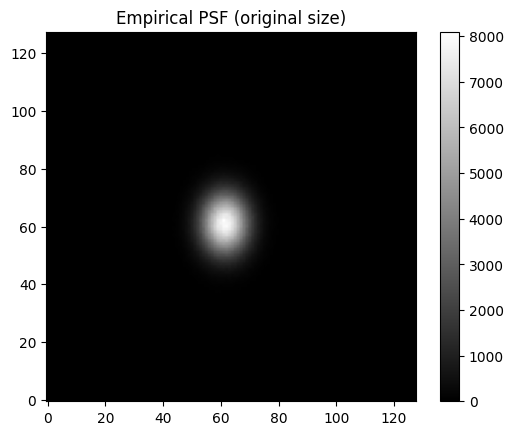

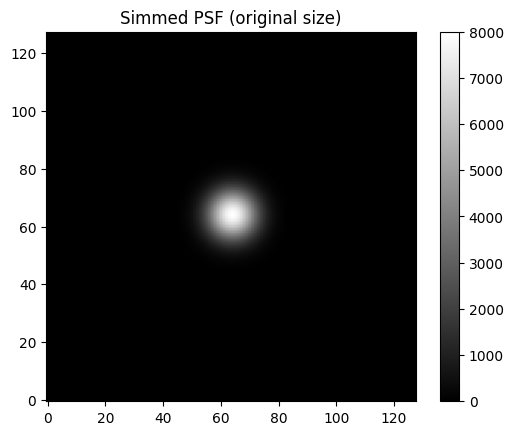

"\n# Plot empirical PSF with Z-scale colorscaling\nzscale = ZScaleInterval()\nvmin_emp, vmax_emp = zscale.get_limits(psf_empirical)\nplt.figure()\nplt.imshow(psf_empirical, origin='lower', cmap='gray', vmin=vmin_emp, vmax=vmax_emp)\nplt.title('Empirical PSF (Z-Scaled)')\nplt.colorbar()\nplt.show()\n\n# Plot simmed PSF with Z-scale colorscaling\nvmin_sim, vmax_sim = zscale.get_limits(psf_simmed)\nplt.figure()\nplt.imshow(psf_simmed, origin='lower', cmap='gray', vmin=vmin_sim, vmax=vmax_sim)\nplt.title('Simmed PSF (Z-Scaled)')\nplt.colorbar()\nplt.show()\n"

In [5]:
# original sizes

plt.clf()
plt.imshow(psf_empirical, origin='lower', cmap='gray')
plt.title('Empirical PSF (original size)')
plt.colorbar()
plt.show()

plt.clf()
plt.imshow(psf_simmed, origin='lower', cmap='gray')
plt.title('Simmed PSF (original size)')
plt.colorbar()
plt.show()

'''
# Plot empirical PSF with Z-scale colorscaling
zscale = ZScaleInterval()
vmin_emp, vmax_emp = zscale.get_limits(psf_empirical)
plt.figure()
plt.imshow(psf_empirical, origin='lower', cmap='gray', vmin=vmin_emp, vmax=vmax_emp)
plt.title('Empirical PSF (Z-Scaled)')
plt.colorbar()
plt.show()

# Plot simmed PSF with Z-scale colorscaling
vmin_sim, vmax_sim = zscale.get_limits(psf_simmed)
plt.figure()
plt.imshow(psf_simmed, origin='lower', cmap='gray', vmin=vmin_sim, vmax=vmax_sim)
plt.title('Simmed PSF (Z-Scaled)')
plt.colorbar()
plt.show()
'''




In [14]:
# oversampled

# Define oversampling factor
oversample_factor = 4

# Step 1: Oversample the PSFs by a factor of 4 using bicubic interpolation
psf_empirical_oversamp = zoom(psf_empirical, oversample_factor, order=3)
psf_simmed_oversamp = zoom(psf_simmed, oversample_factor, order=3)

# Step 2: Define a loss function for registering the simulated PSF to the empirical PSF
def registration_loss(shift_vals, psf_simmed_os, psf_empirical_os):
    """
    Compute the loss (sum of squared differences) between the
    shifted, oversampled simulated PSF and the oversampled empirical PSF.
    """
    shifted_psf = shift(psf_simmed_os, shift=shift_vals, order=3, mode='nearest')
    # Crop to smallest matching size if necessary
    min_shape = (
        min(shifted_psf.shape[0], psf_empirical_os.shape[0]),
        min(shifted_psf.shape[1], psf_empirical_os.shape[1])
    )
    psf1_crop = shifted_psf[:min_shape[0], :min_shape[1]]
    psf2_crop = psf_empirical_os[:min_shape[0], :min_shape[1]]
    return np.sum((psf1_crop - psf2_crop) ** 2)

# Step 3: Optimize the 2D shift using scipy.optimize.minimize
# Initial guess is no shift
initial_shift = [0, 0]
result = minimize(
    registration_loss, initial_shift,
    args=(psf_simmed_oversamp, psf_empirical_oversamp),
    bounds=((-oversample_factor, oversample_factor), (-oversample_factor, oversample_factor)),
    method='L-BFGS-B'
)
best_shift = result.x

# Step 4: Apply the best shift to the oversampled simulated PSF
psf_simmed_matched = shift(psf_simmed_oversamp, shift=best_shift, order=3, mode='nearest')

# Step 5: Find the exact center of the shifted, oversampled simulated PSF
# Here we use centroid calculation (center-of-mass)
exact_center = center_of_mass(psf_simmed_matched)


In [15]:
exact_center

(253.51181101453398, 253.51181101453406)

In [6]:
# cross-correlate the oversampled PSFs to find the exact center of the oversampledempirical PSF
# then convert that to the exact center of the original PSF

# Define oversampling factor
oversample_factor = 4

# Step 1: Oversample the PSFs by a factor of 4 using bicubic interpolation
psf_empirical_oversamp = zoom(psf_empirical, oversample_factor, order=3)
psf_simmed_oversamp = zoom(psf_simmed, oversample_factor, order=3)

# signal.correlate2d(face, template); template is the thing whose center we want to find
corr = signal.correlate2d(psf_simmed_oversamp, psf_empirical_oversamp, boundary='symm', mode='same')


In [9]:
# find the indices of the match
yo_retrieved_simmed_size, xo_retrieved_simmed_size = np.unravel_index(np.argmax(corr), corr.shape)  # find the match


In [18]:
# convert the center of the oversampled PSF to the center of the original PSF
center_x_original_1 = xo_retrieved_simmed_size / oversample_factor
center_y_original_1 = yo_retrieved_simmed_size / oversample_factor
center_x_original_2 = exact_center[1] / oversample_factor
center_y_original_2 = exact_center[0] / oversample_factor

print(f'Center of oversampled empirical PSF, algorithm 1: ({xo_retrieved_simmed_size}, {yo_retrieved_simmed_size})')
print(f'Center of original empirical PSF, algorithm 1: ({center_x_original_1}, {center_y_original_1})')
print(f'Injected center of simmed PSF, algorithm 1: ({xo_injected}, {yo_injected})')
print(f'Difference, algorithm 1: {xo_injected - center_x_original_1}, {yo_injected - center_y_original_1}')
print('--------------------------------')
print(f'Center of oversampled empirical PSF, algorithm 2: ({exact_center[1]}, {exact_center[0]})')
print(f'Center of original empirical PSF, algorithm 2: ({center_x_original_2}, {center_y_original_2})')
print(f'Injected center of simmed PSF, algorithm 2: ({xo_injected}, {yo_injected})')
print(f'Difference, algorithm 2: {xo_injected - center_x_original_2}, {yo_injected - center_y_original_2}')



Center of oversampled empirical PSF, algorithm 1: (265, 267)
Center of original empirical PSF, algorithm 1: (66.25, 66.75)
Injected center of simmed PSF, algorithm 1: (61.4, 60.9)
Difference, algorithm 1: -4.850000000000001, -5.850000000000001
--------------------------------
Center of oversampled empirical PSF, algorithm 2: (253.51181101453406, 253.51181101453398)
Center of original empirical PSF, algorithm 2: (63.377952753633515, 63.377952753633494)
Injected center of simmed PSF, algorithm 2: (61.4, 60.9)
Difference, algorithm 2: -1.9779527536335166, -2.4779527536334953


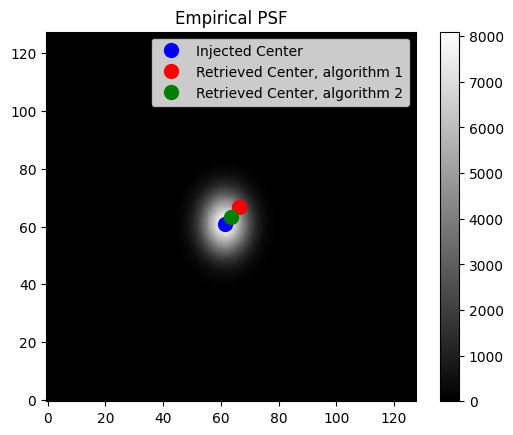

In [19]:
plt.figure()
plt.imshow(psf_empirical, origin='lower', cmap='gray')
plt.title('Empirical PSF')

# Plot injected center (assume from context: xo_injected, yo_injected)
plt.plot(xo_injected, yo_injected, 'bo', markersize=10, label='Injected Center')

# Plot retrieved center (in original PSF coords)
plt.plot(center_x_original, center_y_original, 'ro', markersize=10, label='Retrieved Center, algorithm 1')
plt.plot(center_x_original_2, center_y_original_2, 'go', markersize=10, label='Retrieved Center, algorithm 2')

plt.legend()
plt.colorbar()
plt.show()
